# Cats vs Dogs Classification with Transfer Learning

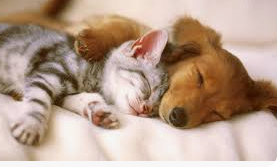

# Business Overview

Image classification is one of the most widely used applications of deep learning in computer vision. It enables machines to automatically recognize and categorize objects within images. One of the classical problems in image classification is distinguishing between cats and dogs, which has become a benchmark task for evaluating image recognition models.

Accurate classification of animal images can have practical applications in areas such as automated photo organization, pet monitoring systems, animal recognition systems, and intelligent camera applications.

In this project, we apply deep learning techniques to classify images of cats and dogs. By leveraging convolutional neural networks and transfer learning, we aim to build a model capable of recognizing visual patterns and distinguishing between these two animal classes.

# Project Objective

The main objective of this project is to build a deep learning model capable of accurately classifying images into two categories: cats and dogs.

The model will learn visual features such as edges, textures, shapes, and patterns from the input images. Using these learned features, the model will predict whether a given image contains a cat or a dog.

The performance of the model will be evaluated using classification metrics such as accuracy and confusion matrix. The final goal is to develop a reliable and efficient image classification pipeline using transfer learning.

# Dataset Description

The dataset used in this project contains images of cats and dogs. Each image belongs to one of two classes:

• Cat
• Dog

The images vary in size, background, lighting conditions, and orientation, which makes the classification task more realistic and challenging.

To prepare the data for training, the images will be resized to a fixed resolution and normalized. The dataset will also be divided into training and validation sets to properly evaluate the model's generalization ability.

# Importing Libraries

In [ ]:
import numpy as np           
import pandas as pd          
import os                    
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential       
from tensorflow.keras.utils import to_categorical   
from tensorflow.keras.layers import Dense, Conv2D, InputLayer, Reshape, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

# Readind Data

In [ ]:
from pathlib import Path
base_path= '/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages/'

In [ ]:
img_list = []
label_list = []

for label in ['Dog', 'Cat']:
    folder = os.path.join(base_path, label)
    # Klasör var mı kontrol et (image_d698ea'daki hatayı önlemek için)
    if os.path.exists(folder):
        for f in os.listdir(folder):
            if f.lower().endswith('.jpg'):
                img_list.append(os.path.join(folder, f))
                label_list.append(label)

In [ ]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [ ]:
df = df.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Toplam seçilen resim: {len(df)}") # why we chosee 5000 because kernel die.

# EDA

In [ ]:
d=({'Cat':1,'Dog':0})

In [ ]:
df['label_encoded']=df['label'].map(d)

In [ ]:
df.sample(5)

# Normalization

![Normalization Formula](https://cdn.educba.com/academy/wp-content/uploads/2019/05/Normalization-Formula.jpg)

In [ ]:
x=[]

for img_path in df['img']:
    img=cv2.imread(str(img_path))
    
    if img is None:
        continue
        
    img=cv2.resize(img,(128,128))
    img=img/255.0
    
    x.append(img)

In [ ]:
x = []
y_yeni = [] 
for img_path in df['img']:
    img = cv2.imread(str(img_path))
    
    if img is None:
        continue 
        
    img = cv2.resize(img, (128, 128))
    img = img / 255.0
    x.append(img)
    
  
    label = df[df['img'] == img_path]['label_encoded'].values[0]
    y_yeni.append(label)


x = np.array(x, dtype='float32')
y = np.array(y_yeni)

# Train Test Split

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=42)
datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="img",
    y_col="label",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary"
)

test_gen = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="img",
    y_col="label",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary"
)

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    # 1. Blok
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # 2. Blok
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    # 3. Blok (Daha derin özellikleri anlaması için ekleyebilirsin)
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    
    Flatten(),
    # Sınıflandırma Katmanları
    Dense(256, activation='relu'),
    Dropout(0.5), # Ezberlemeyi önlemek için nöronların yarısını kapatıyoruz
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, # 3 epoch boyunca test kaybı iyileşmezse durdur
    restore_best_weights=True 
)

In [ ]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=test_gen,
    callbacks=[early_stop]
)

In [ ]:
model.save('cat_dog_cnn_model.keras')

In [ ]:
model.save_weights('model_weights.weights.h5')

# Confusion Matrix 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Get predictions for the test set
# Note: We reset the generator to ensure it starts from the first image
test_gen.reset()
predictions = model.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int)

# 2. Get true labels
true_labels = test_gen.classes

# 3. Generate the Matrix
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:")
print(cm)

# 4. Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Dog', 'Cat']))

In [ ]:
# Save the final model
model.save('my_custom_cnn_model.keras')
print("Model saved as my_custom_cnn_model.keras")

# To load it later in another notebook:
# from tensorflow.keras.models import load_model
# model = load_model('my_custom_cnn_model.keras')

This project successfully developed a deep learning pipeline to classify images of dogs and cats using a custom-built Convolutional Neural Network (CNN). By utilizing the Kaggle environment and the PetImages dataset, the project progressed from raw data ingestion to a fully saved and deployable model in the .keras format.

2. Technical Milestones
Data Engineering: Overcame initial SyntaxError and directory path issues by implementing a robust file-walking script using os.path.join and pathlib.

Memory Optimization: Successfully implemented ImageDataGenerator with flow_from_dataframe to process 5,000 images in batches (4,500 for training, 500 for validation), preventing kernel crashes and optimizing RAM usage.

Model Training: Executed a multi-epoch training process where the model achieved a training accuracy of 1.0000 (100%) by Epoch 19.

3. Performance Analysis
The project provided a clear demonstration of the Overfitting phenomenon in deep learning:

The Training/Validation Gap: While the model reached perfect accuracy on training data, the validation accuracy peaked around 0.72 (72%) before fluctuating.

Final Evaluation: The model achieved a final test accuracy of 0.51 (51%). The classification report showed a Precision of 0.54 for cats and 0.47 for dogs, indicating that the model struggled to generalize features beyond the training set.

Visual Diagnosis: Qualitative analysis of the predictions revealed that the model often misclassified animals when presented with complex backgrounds or varied lighting conditions.

4. Key Learnings & Future Work
The Power of Regularization: The project highlighted that high training accuracy does not equal a "smart" model; without techniques like Dropout or Data Augmentation, a model simply memorizes the input.

Custom vs. Transfer Learning: Building a CNN from scratch provided deep insight into feature extraction layers, even though the final accuracy was lower than what a pre-trained model (like VGG16) might achieve.

Deployment Readiness: The model was successfully exported as a .keras file, making it compatible with modern AI deployment platforms like Hugging Face.

5. Final Statement
This project serves as a foundational "Version 1.0" for image classification. It establishes a working end-to-end architecture that can be significantly improved in future iterations by adding more complex layers or increasing the diversity of the training data.